In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import requests
import io
import matplotlib.colors as mcolors

### Import Data

In [ ]:
url3="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/vertical_velocity.nc"
response=requests.get(url3)
data=response.content
a=xr.open_dataset(io.BytesIO(data),engine="netcdf4")
w_prime=np.array(a["w_fluct"])

## Energy Spectrum

In [180]:
def Energy_Spectrum(w_fluct,check_variance=True):

    ny, nx = w_fluct.shape
    dx=dy=50
    N=nx*ny

    # -------------------------------
    # 1. 2D FFT
    # -------------------------------
    W = np.fft.fft2(w_fluct)

    # -------------------------------
    # 2. Wavenumber arrays
    # -------------------------------
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)

    # Units:
    # kx, ky : 1/m

    dkx = abs(kx[1] - kx[0])
    dky = abs(ky[1] - ky[0])

    # -------------------------------
    # 3. Physical 2D spectral density
    # -------------------------------
    E2d = (((dx*dy)/N)*np.abs(W)**2)

    # Units:
    # E2d : m^4/s^2

    # Check:
    # sum(E2d) * dkx * dky / (2*pi)^2 = variance of w

    variance_direct = np.mean(w_fluct**2)
    variance_from_2d_spectrum = (np.sum(E2d) * dkx * dky) / (2*np.pi)**2 
    
    # -------------------------------
    # 4. Radial wavenumber
    # -------------------------------
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    # Units:
    # K : rad/m
    
    # -------------------------------
    # 5. Flatten arrays
    # -------------------------------
    k_flat = K.flatten()
    E_flat = E2d.flatten()

    # Remove k = 0 mode
    mask = k_flat > 0
    k_flat = k_flat[mask]
    E_flat = E_flat[mask]
    
    # -------------------------------
    # 6. linear bins
    # -------------------------------

    kmin = k_flat.min()
    kmax = k_flat.max()

    dk = min(dkx, dky)
 
    k_edges = np.arange(0, kmax + dk, dk)

    k_bin = 0.5 * (k_edges[:-1] + k_edges[1:])  # Centered value between the edges 
       
    # -------------------------------
    # 7. Compute 1D radial spectrum
    # -------------------------------
    nbins = len(k_edges) - 1
    E1d = np.zeros(nbins)
    counts = np.zeros(nbins)

    for i in range(nbins):

        shell_mask = (k_flat >= k_edges[i]) & (k_flat < k_edges[i+1])

        counts[i] = np.sum(shell_mask)

        dk_shell = k_edges[i+1] - k_edges[i]

        if counts[i] > 0:

            # Energy contained in this annular shell
            shell_energy = (np.sum(E_flat[shell_mask])* dkx * dky/ (2*np.pi)**2)

            # Convert shell energy to 1D spectrum
            E1d[i] = shell_energy / dk_shell
        else:
            E1d[i] = np.nan

    # Units:
    # k_bin : rad/m
    # E1d   : m^3/s^2 
    
    # -------------------------------
    # 8. Check variance conservation
    # -------------------------------
    variance_from_1d_spectrum = np.nansum(E1d * np.diff(k_edges))

    valid=(counts>0) & np.isfinite(E1d)
    E1d=E1d[valid]
    k_bin=k_bin[valid]

    if check_variance:
        print("="*50)
        print(f"variance direct = {variance_direct:.8e}")
        print(f"variance from 2D spectrum = {variance_from_2d_spectrum:.8e}")
        print(f"Relative Error = {100*(variance_from_2d_spectrum-variance_direct):8.8f}%")
        print("-"*50)
        print(f"variance from 1D radial spectrum = {variance_from_1d_spectrum:.8e}")
        print(f"Relative Error = {100*(variance_from_1d_spectrum-variance_direct):8.8f}%")
        print("="*50)
        print("*"*50)

    return k_bin,E1d  

k1,E1 = Energy_Spectrum(w_prime[75,:,:])
k2,E2 = Energy_Spectrum(w_prime[60,:,:])
k3,E3 = Energy_Spectrum(w_prime[42,:,:])

variance direct = 2.35837282e-02
variance from 2D spectrum = 2.35837282e-02
Relative Error = 0.00000000%
--------------------------------------------------
variance from 1D radial spectrum = 2.35837126e-02
Relative Error = -0.00000156%
**************************************************
variance direct = 2.47814044e-01
variance from 2D spectrum = 2.47814044e-01
Relative Error = -0.00000000%
--------------------------------------------------
variance from 1D radial spectrum = 2.47814012e-01
Relative Error = -0.00000316%
**************************************************
variance direct = 3.78713825e-01
variance from 2D spectrum = 3.78713825e-01
Relative Error = 0.00000000%
--------------------------------------------------
variance from 1D radial spectrum = 3.78709116e-01
Relative Error = -0.00047091%
**************************************************


## Peak Wave Number and Eddy Size

In [163]:
K=[k1,k2,k3]
E=[E1,E2,E3]
L_peak=[]
for k,e in zip(K,E):
    idx_peak = np.nanargmax(e)
    k_peak = k[idx_peak]
    L_peak.append( 2*np.pi / k_peak)

## Visualization

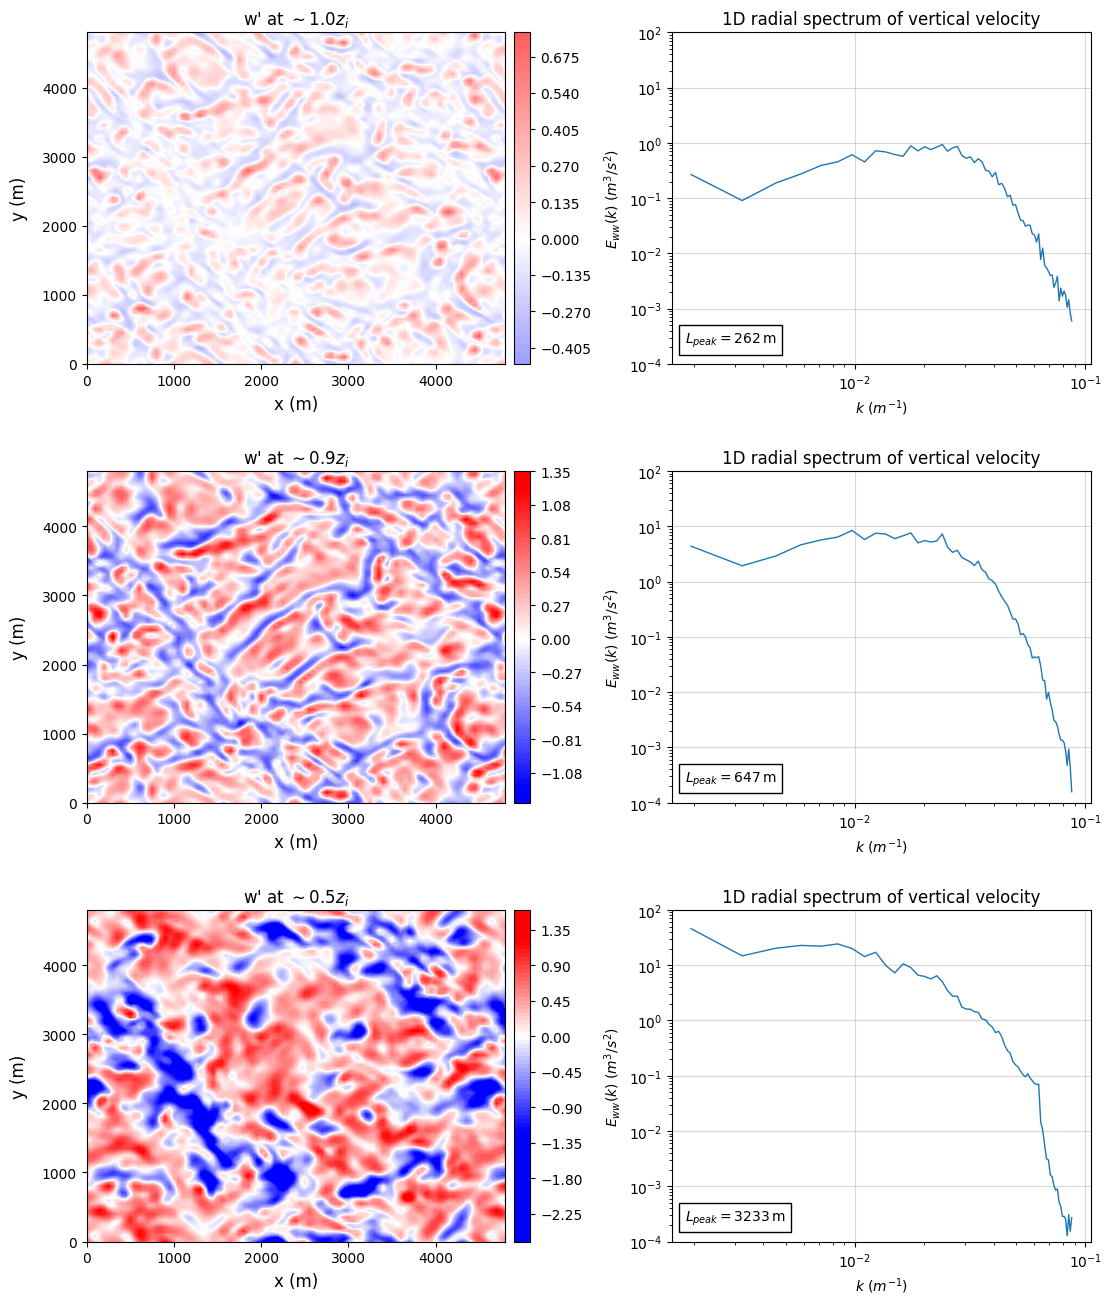

In [179]:
fig,ax=plt.subplots(3,2,figsize=(11,13),constrained_layout={'hspace': 0.07, 'h_pad': 0.07})
f_plot = [w_prime[75,:,:], E1, w_prime[65,:,:], E2, w_prime[42,:,:], E3]
f_title=[r"w' at $\sim 1.0z_{i}$",r"w' at $\sim 0.9z_{i}$",r"w' at $\sim 0.5z_{i}$" ]
for i,axs in enumerate(ax.flat):
    if i % 2 == 0:
        cf=axs.contourf(x,y,f_plot[i],cmap="bwr",levels=100,vmin=-1.2,vmax=1.2)
        axs.set_title(f_title[i//2])
        axs.set_xlabel("x (m)", fontsize=12, labelpad=5)
        axs.set_ylabel("y (m)", fontsize=12, labelpad=10)
        cbar = fig.colorbar(cf, ax=axs, orientation="vertical", pad=0.02)
    else:
        axs.loglog(K[i // 2],f_plot[i],lw=1)
        axs.grid(alpha=0.5)
        axs.set_ylim([1e-4,100])
        axs.set_title("1D radial spectrum of vertical velocity")
        axs.set_xlabel(r"$k$ $(m^{-1})$")
        axs.set_ylabel(r"$E_{ww}(k)$ ($m^3/s^2$)")
        axs.text(0.03,0.1,rf"$L_{{peak}}={L_peak[i // 2]:.0f}\,\mathrm{{m}}$",
                 transform=axs.transAxes,fontsize=10,verticalalignment="top",bbox=dict(facecolor="white"))
        

## Results and Discussion

<div style="text-align: justify;
text-justify: inter-word; font-size: 17px;">

The energy spectrum was computed directly by applying the Fast Fourier Transform (FFT) to the vertical velocity fluctuations at three different height levels. To verify the implementation, the direct variance of the fluctuations was calculated and compared with the variance obtained from both the two-dimensional energy spectrum and the one-dimensional radial spectrum. For the selected layers, as well as for all other investigated levels, the percentage error was found to be close to zero, providing confidence in the methodology and confirming variance conservation.

In principle, the analysis could be restricted to wavenumbers below the effective cut-off, $k<2k_c/3$, where $k_c=1/\Delta x$ and $\Delta x=\Delta y=50,\mathrm{m}$. However, this filtering was omitted in the present analysis. Along with the one-dimensional radial energy spectra, contour plots of the vertical velocity fluctuations are presented to facilitate direct comparisons between the dominant turbulent structures and the spectral characteristics.

The most energetic eddies were identified by locating the peak of the energy spectrum. The corresponding characteristic length scale was estimated from the peak wavenumber as

$
L_{\mathrm{peak}}=\frac{2\pi}{k_{\mathrm{peak}}},
$

 The results indicate an increase in the characteristic eddy size from the cloud layer towards the middle of the atmospheric boundary layer (ABL). Turbulent structures within the cloud are smaller than those found in the middle of the mixed layer, which is consistently reflected by the shift of the spectral peak towards lower wavenumbers. For example, at approximately $0.8z_i$, the estimated peak length scale was about $750,\mathrm{m}$, indicating a progressive increase in the size of the dominant turbulent structures towards the middle of the ABL.

Below the middle of the ABL, the computed length scales should be interpreted with caution. In this region, the turbulent fluctuations are preferentially aligned with the mean wind direction rather than with the Cartesian coordinate axes (see the corresponding analysis of turbulent structures). This anisotropy is also evident, although less pronounced, in the present spectral analysis. Consequently, because the energy spectrum is also computed as a one-dimensional radial spectrum, the estimated length scales should be regarded as characteristic turbulence scales rather than the actual streamwise $L_{x}$ or spanwise $L_{y}$ dimensions of the coherent structures

</div>